Feature Importance  - General Protective Behaviour 

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib



Processing Australian Capital Territory
Feature Importance                                       Feature  Importance
6            protective_behavior_nomask_scale    0.421988
8                         7days_rolling_cases    0.083362
7                                        week    0.053391
2                              household_size    0.043309
42          Can't control worrying_Not at all    0.039430
1                                         age    0.036509
5                    Perceived Susceptibility    0.032737
0                      Non-household contacts    0.027276
20                  employment_status_Retired    0.027234
11                      Isolate if unwell_Yes    0.026401
4                          Perceived Severity    0.026267
17                                gender_Male    0.024865
3                                   Wellbeing    0.019385
49  How Government handle situation_Very well    0.016752
34        Feeling down/depressed_Several days    0.015787


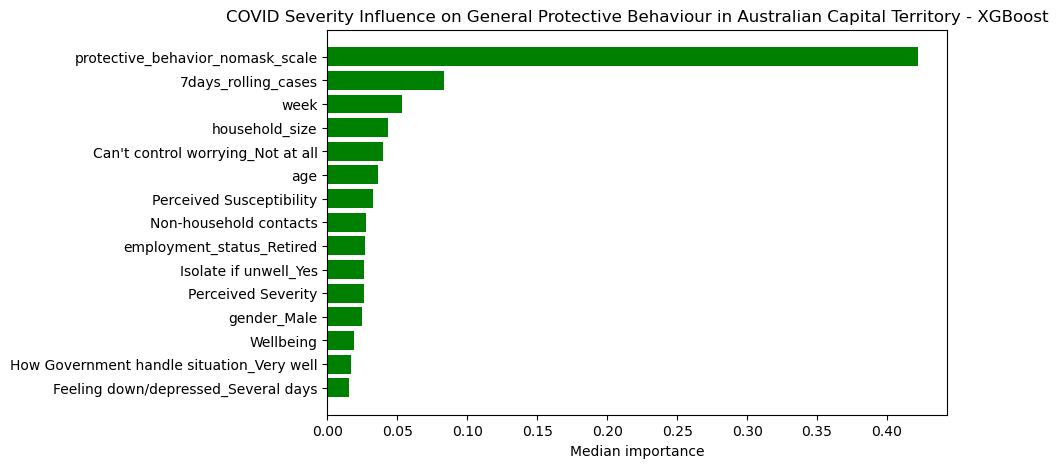


Processing New South Wales
Feature Importance                                               Feature  Importance
6                    protective_behavior_nomask_scale    0.479960
7                                                week    0.046917
8                                 7days_rolling_cases    0.043529
16                 Isolate if instructed_Very willing    0.027454
4                                  Perceived Severity    0.020889
42                  Can't control worrying_Not at all    0.015644
0                              Non-household contacts    0.015607
14             Isolate if instructed_Somewhat willing    0.015558
5                            Perceived Susceptibility    0.014406
11                              Isolate if unwell_Yes    0.013386
24  Confidence in Goverment's response_No confiden...    0.012633
1                                                 age    0.012030
27                Pleasure in doing things_Not at all    0.011756
21                       empl

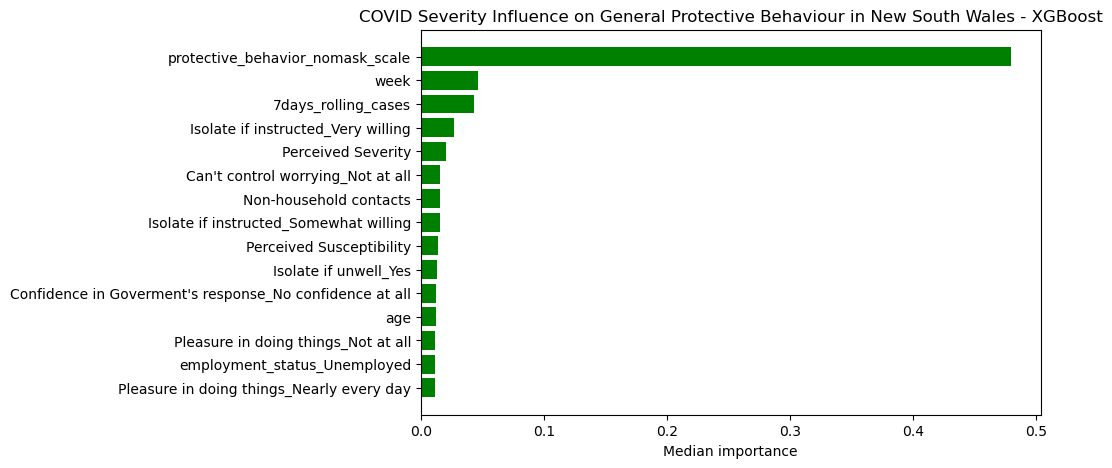


Processing Northern Territory
Feature Importance                                           Feature  Importance
6                protective_behavior_nomask_scale    0.449576
0                          Non-household contacts    0.068366
17                                    gender_Male    0.055957
4                              Perceived Severity    0.053368
7                                            week    0.050411
8                             7days_rolling_cases    0.045200
44            Can't control worrying_Several days    0.042419
3                                       Wellbeing    0.038398
2                                  household_size    0.038173
47  How Government handle situation_Somewhat well    0.037210
51                              comorbidities_Yes    0.025981
1                                             age    0.022422
5                        Perceived Susceptibility    0.021214
42              Can't control worrying_Not at all    0.016622
39           Feeling

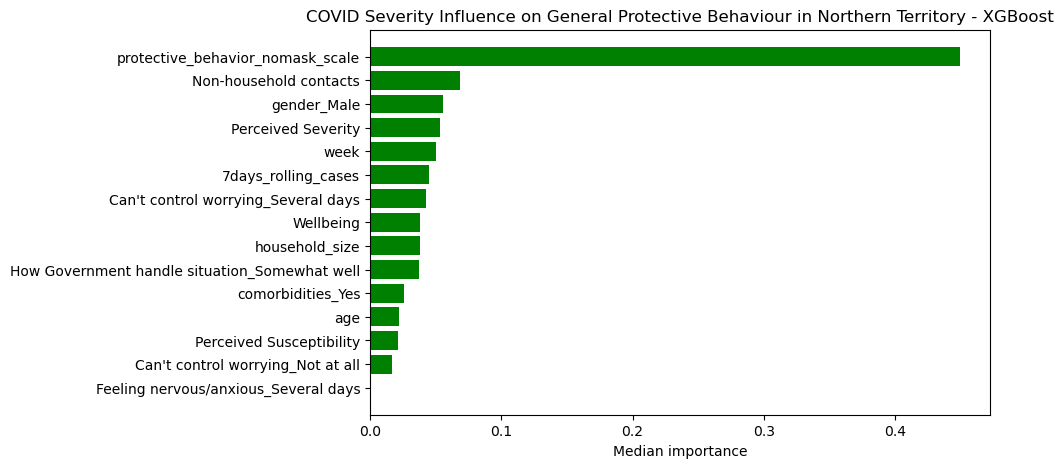


Processing Queensland
Feature Importance                                               Feature  Importance
6                    protective_behavior_nomask_scale    0.450790
7                                                week    0.046656
9                                7days_rolling_deaths    0.033436
37                 Feeling nervous/anxious_Not at all    0.026081
4                                  Perceived Severity    0.024284
27                Pleasure in doing things_Not at all    0.023465
8                                 7days_rolling_cases    0.022358
5                            Perceived Susceptibility    0.022254
16                 Isolate if instructed_Very willing    0.021036
42                  Can't control worrying_Not at all    0.020148
32                  Feeling down/depressed_Not at all    0.018455
0                              Non-household contacts    0.016312
2                                      household_size    0.014393
22  Confidence in Goverment's resp

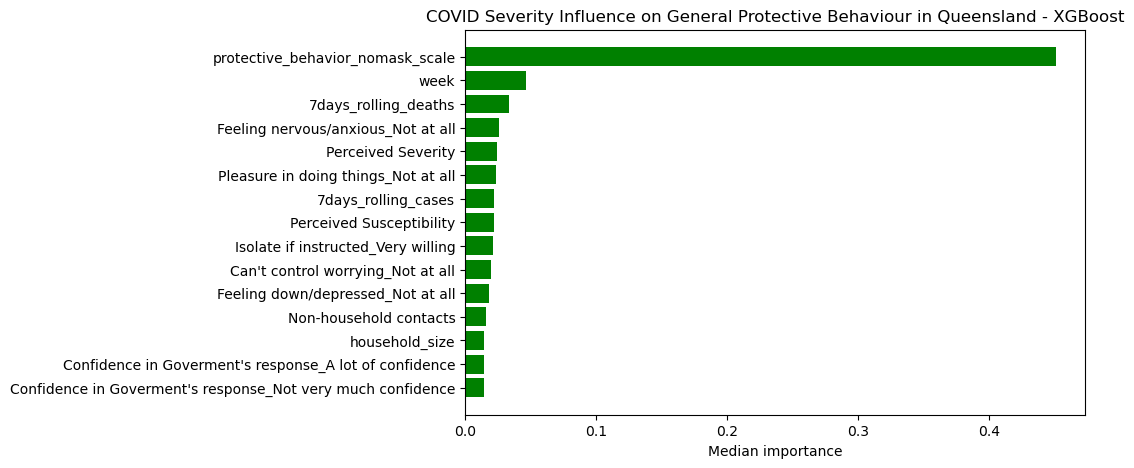


Processing South Australia
Feature Importance                                     Feature  Importance
6          protective_behavior_nomask_scale    0.516828
7                                      week    0.087616
0                    Non-household contacts    0.036246
5                  Perceived Susceptibility    0.033161
10               Isolate if unwell_Not sure    0.030041
16       Isolate if instructed_Very willing    0.026365
11                    Isolate if unwell_Yes    0.026157
41  Can't control worrying_Nearly every day    0.022575
8                       7days_rolling_cases    0.020624
14   Isolate if instructed_Somewhat willing    0.020109
39     Feeling nervous/anxious_Several days    0.019319
32        Feeling down/depressed_Not at all    0.018543
1                                       age    0.017868
3                                 Wellbeing    0.017754
2                            household_size    0.017162


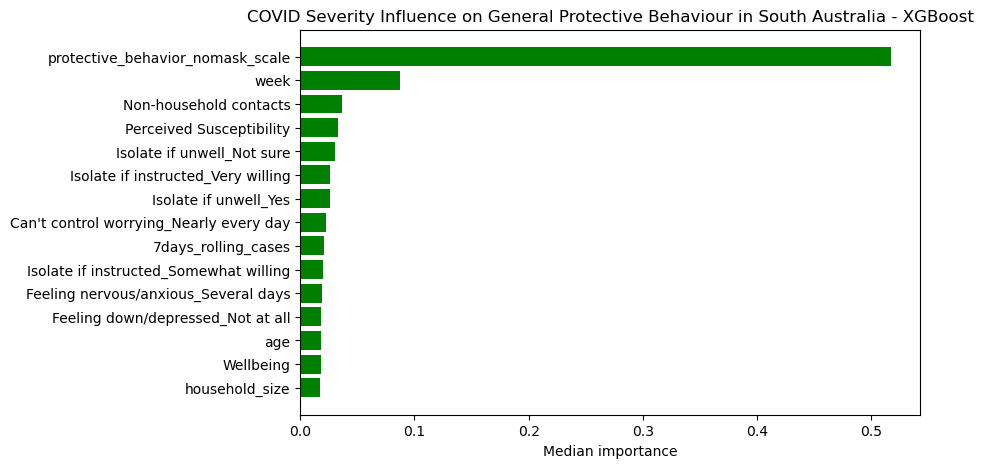


Processing Tasmania
Feature Importance                                           Feature  Importance
6                protective_behavior_nomask_scale    0.550487
8                             7days_rolling_cases    0.038232
30       Pleasure in doing things_consent_removed    0.037292
7                                            week    0.034658
0                          Non-household contacts    0.030456
14         Isolate if instructed_Somewhat willing    0.029391
5                        Perceived Susceptibility    0.027249
4                              Perceived Severity    0.024990
1                                             age    0.024890
11                          Isolate if unwell_Yes    0.024322
51                              comorbidities_Yes    0.022976
47  How Government handle situation_Somewhat well    0.022290
44            Can't control worrying_Several days    0.022114
19         employment_status_Part time employment    0.019992
3                             

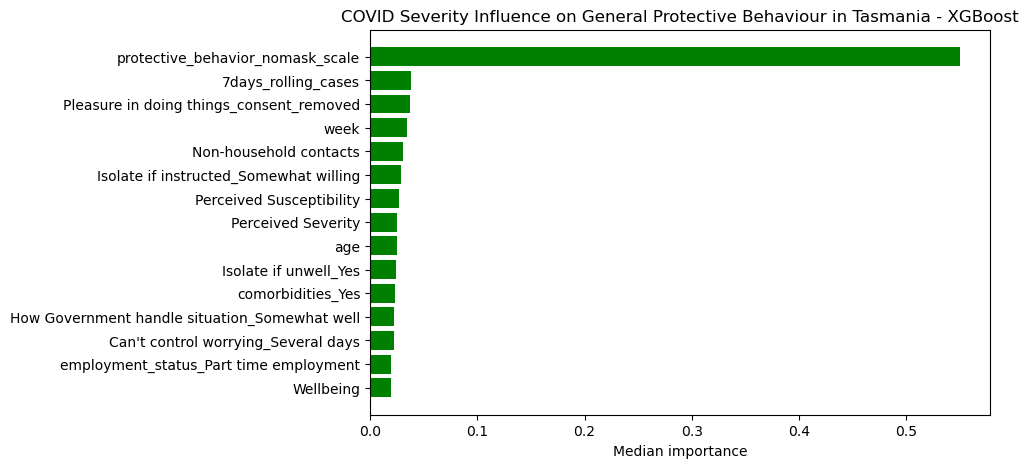


Processing Victoria
Feature Importance                                               Feature  Importance
6                    protective_behavior_nomask_scale    0.455488
7                                                week    0.041425
16                 Isolate if instructed_Very willing    0.029440
37                 Feeling nervous/anxious_Not at all    0.025169
11                              Isolate if unwell_Yes    0.022038
8                                 7days_rolling_cases    0.021253
48         How Government handle situation_Very badly    0.018370
13           Isolate if instructed_Somewhat unwilling    0.017683
24  Confidence in Goverment's response_No confiden...    0.016599
2                                      household_size    0.016594
4                                  Perceived Severity    0.016053
10                         Isolate if unwell_Not sure    0.015889
32                  Feeling down/depressed_Not at all    0.015004
14             Isolate if instructed

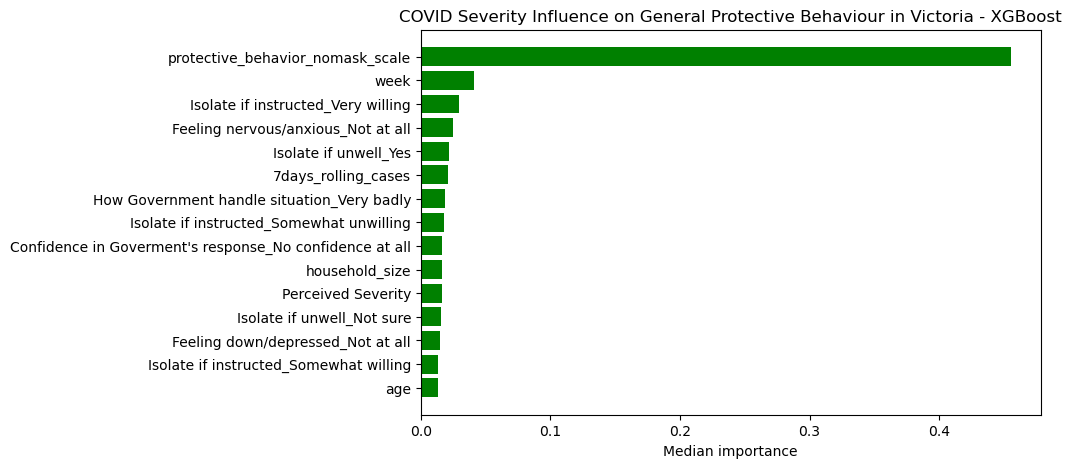


Processing Western Australia
Feature Importance                                               Feature  Importance
6                    protective_behavior_nomask_scale    0.509173
7                                                week    0.032508
2                                      household_size    0.021997
26          Pleasure in doing things_Nearly every day    0.020966
18                      employment_status_Not working    0.020286
8                                 7days_rolling_cases    0.019839
21                       employment_status_Unemployed    0.019282
16                 Isolate if instructed_Very willing    0.019129
34                Feeling down/depressed_Several days    0.018272
29              Pleasure in doing things_Several days    0.017268
22  Confidence in Goverment's response_A lot of co...    0.017133
0                              Non-household contacts    0.015893
44                Can't control worrying_Several days    0.015801
42                  Can't c

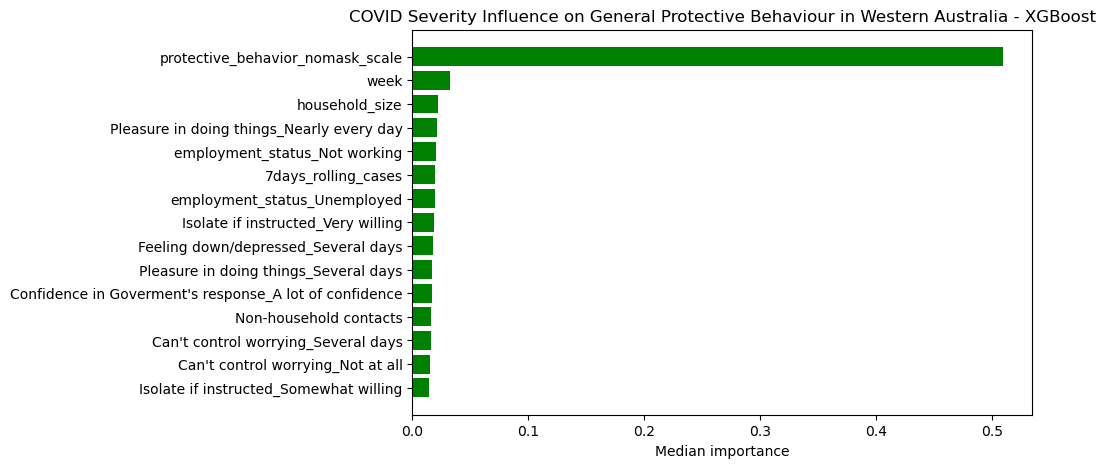

In [2]:
# general protective behaviour train set

state_train_general_behav = pd.read_csv("state_train_general_behav.csv")

states = sorted(state_train_general_behav["state"].unique()) # to get 8 states

# remove the target variables and identifiers
drop_cols = ['RecordNo', 'Date', 'state', 'face_mask_scale', 'face_mask_binary','general_protective_behavior_scale',
                'general_protective_behavior_binary','mandate_start_date','mandate_period']







for state in states: # 8 XGBoost state models

    train_state = state_train_general_behav[state_train_general_behav["state"] == state]

    print(f"\nProcessing {state}")

    # predictors
    x_train = train_state.drop(columns=drop_cols)
    x_train = x_train.astype(float)  # converting boolean to float 


    # target variable
    y_train = train_state["general_protective_behavior_binary"]

    # best rf hyper parameters

    best_parameters = joblib.load(f"RQ2_general_behav_{state}_XGBoost_bestParameters_rolling.pkl")






    # feature importance 


    # to keep all the importances in each run
    all_importances = []


    for i in range(100):
        
        temp_xgb = Pipeline([
        ('ros', RandomOverSampler(random_state=i)),
        ('xgb', XGBClassifier(random_state=i,
                              eval_metric='logloss',
                              n_jobs=-1))
        ])

        temp_xgb.set_params(**best_parameters)

        temp_xgb.fit(x_train, y_train)

        all_importances.append(temp_xgb.named_steps['xgb'].feature_importances_)





    all_importances = np.array(all_importances)

    # take the median / mean
    median_importance = np.median(all_importances, axis=0) # take the median of each column(feature) 


    feature_importance = pd.DataFrame({
        "Feature": x_train.columns,
        "Importance": median_importance
    })

    feature_importance = feature_importance.sort_values("Importance",ascending=False)

    top15 = feature_importance.head(15)

    print(f"Feature Importance",top15)
    feature_importance.to_csv(f"RQ2_general_behav_{state}_XGBoost_FeatureImportance_rolling.csv",index=False)


    # plot
    plt.figure(figsize=(8,5))
    plt.barh(top15["Feature"], top15["Importance"], color="green")
    plt.title(f"COVID Severity Influence on General Protective Behaviour in {state} - XGBoost")
    plt.xlabel("Median importance")
    plt.gca().invert_yaxis()
    plt.savefig(f"RQ2_general_behav_{state}_XGBoost_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")
    plt.show()
